In [1]:
#цвета для графиков
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette=["#1E90FF"],
    rc={
        "figure.facecolor": "#FFF5F7",
        "axes.facecolor": "#FFF5F7",
        "axes.edgecolor": "#E8BFC8",
        "grid.color": "#F2D9DE",
        "text.color": "#6B4C55",
        "axes.labelcolor": "#6B4C55",
        "xtick.color": "#6B4C55",
        "ytick.color": "#6B4C55",
    }
)

In [2]:
import pandas as pd
x = pd.read_csv('ks_восстановленные.csv')
x.head()

,Название,Главная категория,Валюта,Собрано в долларах,Цель в долларах
0,"Don't Call it a Comeback ""Telescopes""",Music,USD,600.00,600.0
1,Me & You Coordinating Sunglasses- Optical Qual...,Film & Video,USD,502.00,10000.0
2,New Carts for Istanbul Street Food Vendors,Food,USD,2414.00,1400.0
3,New Improv Comedy Venue in Des Moines,Theater,USD,10030.88,10000.0
4,The Seer and the Sword,Film & Video,USD,0.00,10000.0


_Изобразим **гистограмму** для колонки Собрано в долларах._

<Axes: xlabel='Собрано в долларах', ylabel='Count'>

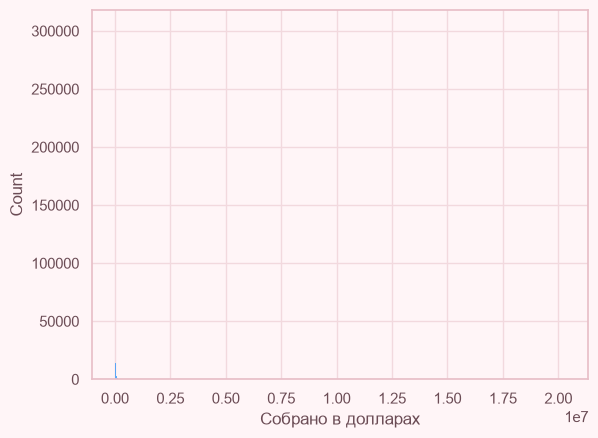

In [3]:
sns.histplot(data=x,
             x='Собрано в долларах')

_Возьмём только значения меньше 2_000._

<Axes: xlabel='Собрано в долларах', ylabel='Count'>

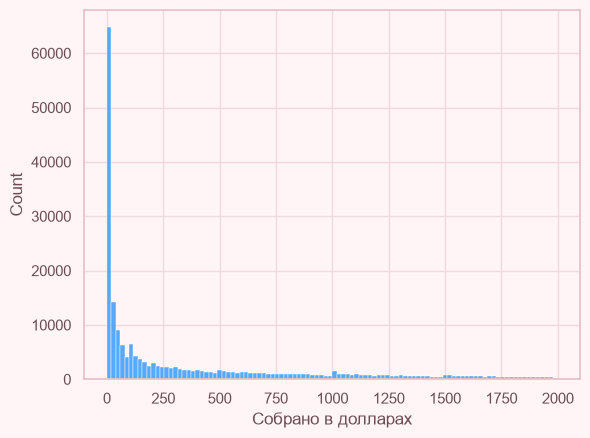

In [4]:
mask = x['Собрано в долларах'] < 2_000

sns.histplot(data=x[mask],
             x='Собрано в долларах')

_Изобразим **ящик с усами** для колонки Собрано в долларах._

(-10000.0, 50000.0)

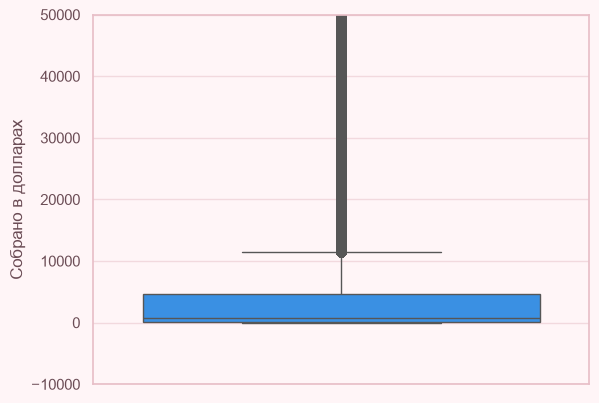

In [13]:
sns.boxplot(y=x['Собрано в долларах'])
#изменим масштаб оси ординат.
plt.ylim(-10_000, 50_000)

_Видим, что у нас очень много выбросов. Минимальное значение, не являющееся выбросом, находится очень близко к медиане данных. Опишем данные._

In [15]:
desc_x = x['Собрано в долларах'].describe()

_Чтобы избавится от выбросов, нам нужно рассчитать какие минимальные и максимальные значения считаются нормальными. Усами станут фактические значения, которые не выходят за эти пределы._

In [19]:
#найдем первый квартиль
q1 = desc_x['25%']
#найдем третий квартиль
q3 = desc_x['75%']
#найдем длинну коробки
iqr = q3 - q1

#поставим вместо стандартных 1.5 значение 3, чтобы сохранить больше объектов
#нижняя граница
m_low = q1 - 3 * iqr
#верхняя граница
m_high = q3 + 3 * iqr

_Теперь уберем выбросы._

In [20]:
mask = x['Собрано в долларах'] <= m_high

x_no_outlier = x[mask]
x_no_outlier.head()

,Название,Главная категория,Валюта,Собрано в долларах,Цель в долларах
0,"Don't Call it a Comeback ""Telescopes""",Music,USD,600.00,600.0
1,Me & You Coordinating Sunglasses- Optical Qual...,Film & Video,USD,502.00,10000.0
2,New Carts for Istanbul Street Food Vendors,Food,USD,2414.00,1400.0
3,New Improv Comedy Venue in Des Moines,Theater,USD,10030.88,10000.0
4,The Seer and the Sword,Film & Video,USD,0.00,10000.0


_Узнаем сколько объектов мы потеряли._

In [21]:
print(x.shape)
print(x_no_outlier.shape)

(331675, 5)
(303961, 5)


_Изобразим ящик снова._

(-10000.0, 50000.0)

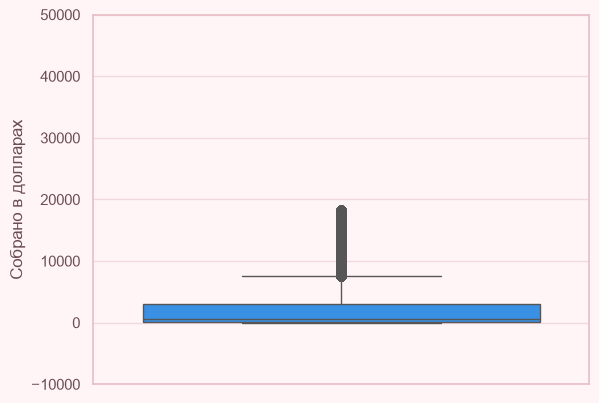

In [23]:
sns.boxplot(y=x_no_outlier['Собрано в долларах'])
#также масштаб оси ординат.
plt.ylim(-10_000, 50_000)